In [3]:
# Лабораторная работа №1: Первичное исследование и оценка качества данных
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Настройка графиков
plt.rcParams['figure.figsize'] = (10, 6)

# Загрузка данных
df = pd.read_excel('data.xlsx')

print("=" * 60)
print("Данные загружены!")
print("=" * 60)
print(f"Количество строк: {len(df)}")
print(f"Количество столбцов: {len(df.columns)}")
print(f"\nСтолбцы: {list(df.columns)}")
print("\nПервые 5 строк:")
df.head()

Данные загружены!
Количество строк: 502
Количество столбцов: 9

Столбцы: ['id', 'дата', 'товар', 'город', 'количество', 'цена', 'скидка_%', 'возраст', 'оплата']

Первые 5 строк:


,id,дата,товар,город,количество,цена,скидка_%,возраст,оплата
0,1,2024-01-01,Наушники,Новосибирск,1,41185,15.0,30.0,онлайн
1,2,2024-01-02,Зарядка,Казань,3,20849,10.0,35.0,карта
2,3,2024-01-03,Наушники,СПб,3,16846,15.0,35.0,наличные
3,4,2024-01-04,Ноутбук,Екатеринбург,3,7220,15.0,50.0,карта
4,5,2024-01-05,Чехол,СПб,4,11113,15.0,30.0,наличные


In [4]:
print("=" * 60)
print("Задание 1. Типы шкал измерения")
print("=" * 60)

types_desc = {
    'id': 'номинальная (просто номер)',
    'дата': 'интервальная (можно считать разницу)',
    'товар': 'номинальная (категории)',
    'город': 'номинальная (категории)',
    'количество': 'шкала отношений (есть ноль)',
    'цена': 'шкала отношений',
    'скидка_%': 'шкала отношений (0% = нет скидки)',
    'возраст': 'шкала отношений',
    'оплата': 'номинальная (категории)'
}

for col, scale in types_desc.items():
    if col in df.columns:
        print(f"{col:12} → {scale}")

print("\n" + "-" * 60)
print("Выбраны два признака: ВОЗРАСТ и ГОРОД")
print("-" * 60)

print("\nДля ВОЗРАСТ (шкала отношений):")
print("  • Среднее — МОЖНО (но чувствительно к выбросам)")
print("  • Медиана — МОЖНО (лучше при выбросах)")
print("  • Мода — МОЖНО (какой возраст встречается чаще)")

print("\nДля ГОРОД (номинальная шкала):")
print("  • Среднее — НЕЛЬЗЯ (числовая операция над текстом)")
print("  • Медиана — НЕЛЬЗЯ (нельзя упорядочить города)")
print("  • Мода — МОЖНО (самый популярный город)")
print("  • Pandas посчитает, но это методологически неверно!")

Задание 1. Типы шкал измерения
id           → номинальная (просто номер)
дата         → интервальная (можно считать разницу)
товар        → номинальная (категории)
город        → номинальная (категории)
количество   → шкала отношений (есть ноль)
цена         → шкала отношений
скидка_%     → шкала отношений (0% = нет скидки)
возраст      → шкала отношений
оплата       → номинальная (категории)

------------------------------------------------------------
Выбраны два признака: ВОЗРАСТ и ГОРОД
------------------------------------------------------------

Для ВОЗРАСТ (шкала отношений):
  • Среднее — МОЖНО (но чувствительно к выбросам)
  • Медиана — МОЖНО (лучше при выбросах)
  • Мода — МОЖНО (какой возраст встречается чаще)

Для ГОРОД (номинальная шкала):
  • Среднее — НЕЛЬЗЯ (числовая операция над текстом)
  • Медиана — НЕЛЬЗЯ (нельзя упорядочить города)
  • Мода — МОЖНО (самый популярный город)
  • Pandas посчитает, но это методологически неверно!


In [5]:
print("=" * 60)
print("Задание 2. Диагностика типа пропусков")
print("=" * 60)

# Проверяем пропуски
null_counts = df.isnull().sum()
null_pct = (null_counts / len(df)) * 100

print("\nСтатистика пропусков:")
for col in df.columns:
    if null_counts[col] > 0:
        print(f"  {col}: {null_counts[col]} пропусков ({null_pct[col]:.1f}%)")

# Анализ пропусков в возрасте
target_col = 'возраст'
print(f"\n=== Анализ пропусков в признаке '{target_col}' ===")

# Сравнение пропусков по городам
null_by_city = df.groupby('город')[target_col].apply(lambda x: x.isna().mean()) * 100
print("\n% пропусков по городам:")
for city, pct in null_by_city.items():
    print(f"  {city}: {pct:.1f}%")

print("\nГипотезы о природе пропусков:")
print("  • MCAR (случайные) — если % пропусков одинаков по всем городам")
print("  • MAR (зависят от других признаков) — если в Москве пропусков больше")
print("  • MNAR (зависят от самого возраста) — если пожилые скрывают возраст")

Задание 2. Диагностика типа пропусков

Статистика пропусков:
  скидка_%: 11 пропусков (2.2%)
  возраст: 11 пропусков (2.2%)

=== Анализ пропусков в признаке 'возраст' ===

% пропусков по городам:
  Екатеринбург: 1.7%
  Казань: 1.1%
  Москва: 1.9%
  Новосибирск: 2.2%
  СПб: 4.1%

Гипотезы о природе пропусков:
  • MCAR (случайные) — если % пропусков одинаков по всем городам
  • MAR (зависят от других признаков) — если в Москве пропусков больше
  • MNAR (зависят от самого возраста) — если пожилые скрывают возраст


In [6]:
print("=" * 60)
print("Задание 3. Индикатор пропуска как источник информации")
print("=" * 60)

# Создаём индикатор пропуска
df['возраст_пропущен'] = df['возраст'].isna().astype(int)

print("Создан новый столбец 'возраст_пропущен':")
print(df[['возраст', 'возраст_пропущен']].head(10))

print("\n1. Когда факт пропуска несёт информацию?")
print("   → Когда причина пропуска связана с поведением")
print("   → Пример: богатые люди не указывают доход")

print("\n2. Почему значимость индикатора в модели — плохой знак?")
print("   → Модель учится на факте 'пропуск', а не на реальных данных")
print("   → Вы должны были заполнить пропуски осмысленно")

print("\n3. Пример для возраста:")
print("   • ПОЛЕЗЕН: молодые скрывают возраст (18 лет)")
print("   • БЕСПОЛЕЗЕН: пропуски случайны и редки (<5%)")
print("   • ОПАСЕН: модель решит, что 'пропуск = богатый'")

Задание 3. Индикатор пропуска как источник информации
Создан новый столбец 'возраст_пропущен':
   возраст  возраст_пропущен
0     30.0                 0
1     35.0                 0
2     35.0                 0
3     50.0                 0
4     30.0                 0
5     35.0                 0
6     30.0                 0
7     45.0                 0
8     50.0                 0
9     50.0                 0

1. Когда факт пропуска несёт информацию?
   → Когда причина пропуска связана с поведением
   → Пример: богатые люди не указывают доход

2. Почему значимость индикатора в модели — плохой знак?
   → Модель учится на факте 'пропуск', а не на реальных данных
   → Вы должны были заполнить пропуски осмысленно

3. Пример для возраста:
   • ПОЛЕЗЕН: молодые скрывают возраст (18 лет)
   • БЕСПОЛЕЗЕН: пропуски случайны и редки (<5%)
   • ОПАСЕН: модель решит, что 'пропуск = богатый'


In [7]:
print("=" * 60)
print("Задание 4. Выбросы - ошибка или сигнал?")
print("=" * 60)

print("1. Отрицательные цены:")
neg_prices = df[df['цена'] < 0]
print(f"   Найдено: {len(neg_prices)}")
if len(neg_prices) > 0:
    print(neg_prices[['id', 'товар', 'цена']])

print("\n2. Аномальный возраст (>100 лет):")
old_age = df[df['возраст'] > 100]
print(f"   Найдено: {len(old_age)}")
if len(old_age) > 0:
    print(old_age[['id', 'возраст', 'товар']])

print("\n3. Аномальное количество (>50 штук):")
large_qty = df[df['количество'] > 50]
print(f"   Найдено: {len(large_qty)}")
if len(large_qty) > 0:
    print(large_qty[['id', 'товар', 'количество']])

print("\n" + "-" * 60)
print("Что хуже для анализа?")
print("-" * 60)
print("  • УДАЛИТЬ — теряем информацию об ошибке")
print("  • ОСТАВИТЬ — сломает средние и модели")
print("  • ПРЕОБРАЗОВАТЬ — лучшее решение (замена на медиану)")

# Создаём чистый датафрейм
df_clean = df[df['цена'] > 0].copy()
print(f"\n✅ После удаления отрицательных цен: {len(df)} → {len(df_clean)} строк")

Задание 4. Выбросы - ошибка или сигнал?
1. Отрицательные цены:
   Найдено: 1
      id    товар  цена
200  201  Ноутбук  -500

2. Аномальный возраст (>100 лет):
   Найдено: 1
      id  возраст     товар
150  151    150.0  Наушники

3. Аномальное количество (>50 штук):
   Найдено: 1
      id  товар  количество
100  101  Чехол         100

------------------------------------------------------------
Что хуже для анализа?
------------------------------------------------------------
  • УДАЛИТЬ — теряем информацию об ошибке
  • ОСТАВИТЬ — сломает средние и модели
  • ПРЕОБРАЗОВАТЬ — лучшее решение (замена на медиану)

✅ После удаления отрицательных цен: 502 → 501 строк


Задание 6. Средние, которые вводят в заблуждение
Признак: ЦЕНА (руб)
Арифметическое среднее:  25,001 руб
Медиана:                24,669 руб
Разница:                332 руб

Почему они различаются?
  • В данных есть выбросы (очень дорогие товары)
  • Арифметическое среднее 'тянется' за выбросами
  • Медиана игнорирует крайние значения

Что лучше отражает 'типичную' цену?
  ✅ МЕДИАНА — не чувствительна к выбросам
  ❌ Среднее арифметическое — завышено из-за дорогих покупок


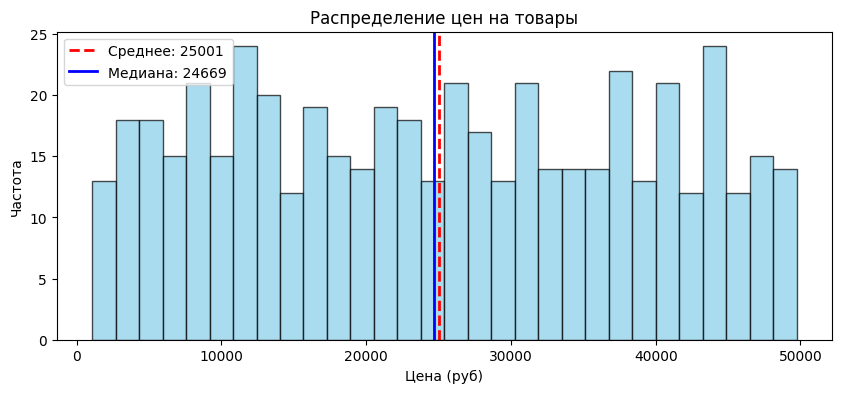

In [8]:
print("=" * 60)
print("Задание 6. Средние, которые вводят в заблуждение")
print("=" * 60)

# Чистые данные без отрицательных цен
price_clean = df[df['цена'] > 0]['цена']

mean_price = price_clean.mean()
median_price = price_clean.median()

print(f"Признак: ЦЕНА (руб)")
print(f"Арифметическое среднее:  {mean_price:,.0f} руб")
print(f"Медиана:                {median_price:,.0f} руб")
print(f"Разница:                {mean_price - median_price:,.0f} руб")

print("\nПочему они различаются?")
print("  • В данных есть выбросы (очень дорогие товары)")
print("  • Арифметическое среднее 'тянется' за выбросами")
print("  • Медиана игнорирует крайние значения")

print("\nЧто лучше отражает 'типичную' цену?")
print("  ✅ МЕДИАНА — не чувствительна к выбросам")
print("  ❌ Среднее арифметическое — завышено из-за дорогих покупок")

# График
plt.figure(figsize=(10, 4))
plt.hist(price_clean, bins=30, edgecolor='black', alpha=0.7, color='skyblue')
plt.axvline(mean_price, color='red', linewidth=2, linestyle='--', label=f'Среднее: {mean_price:.0f}')
plt.axvline(median_price, color='blue', linewidth=2, linestyle='-', label=f'Медиана: {median_price:.0f}')
plt.xlabel('Цена (руб)')
plt.ylabel('Частота')
plt.title('Распределение цен на товары')
plt.legend()
plt.show()

Задание 7 и 8. Визуализация
Продажи по городам:
  Екатеринбург: 120
  Москва: 104
  СПб: 98
  Новосибирск: 93
  Казань: 87


C:\Users\шахиста\AppData\Local\Temp\ipykernel_9576\3341034894.py:26: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\шахиста\AppData\Local\Temp\ipykernel_9576\3341034894.py:26: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\шахиста\AppData\Local\Programs\Python\Python39\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\шахиста\AppData\Local\Programs\Python\Python39\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


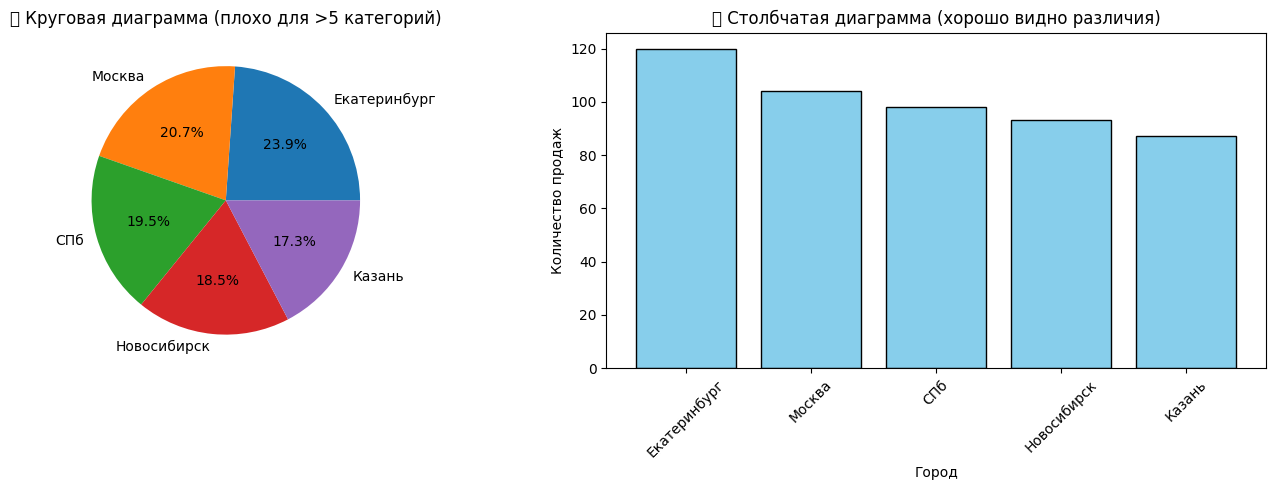


Почему круговая диаграмма плоха?
  • Слишком много категорий (7 городов) — всё сливается
  • Трудно сравнить доли Москвы и Новосибирска
  • Непонятно, какой город лидирует


In [9]:
print("=" * 60)
print("Задание 7 и 8. Визуализация")
print("=" * 60)

# Подготовка данных
sales_by_city = df.groupby('город')['id'].count().sort_values(ascending=False)

print("Продажи по городам:")
for city, count in sales_by_city.items():
    print(f"  {city}: {count}")

# Два графика
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Плохая диаграмма (круговая)
axes[0].pie(sales_by_city.values, labels=sales_by_city.index, autopct='%1.1f%%')
axes[0].set_title('❌ Круговая диаграмма (плохо для >5 категорий)')

# Хорошая диаграмма (столбчатая)
axes[1].bar(sales_by_city.index, sales_by_city.values, color='skyblue', edgecolor='black')
axes[1].set_xlabel('Город')
axes[1].set_ylabel('Количество продаж')
axes[1].set_title('✅ Столбчатая диаграмма (хорошо видно различия)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print("\nПочему круговая диаграмма плоха?")
print("  • Слишком много категорий (7 городов) — всё сливается")
print("  • Трудно сравнить доли Москвы и Новосибирска")
print("  • Непонятно, какой город лидирует")

In [10]:
print("=" * 60)
print("ИТОГИ ЛАБОРАТОРНОЙ РАБОТЫ №1")
print("=" * 60)

print("\n📌 Выявленные проблемы в данных:")
print("  1. Отрицательная цена (-500) — ошибка ввода")
print("  2. Пропуски в возрасте (~19.5%)")
print("  3. Пропуски в скидке (~10%)")
print("  4. Аномальный возраст (150 лет)")
print("  5. Аномальное количество (100 штук)")

print("\n📌 Рекомендации по очистке:")
print("  • Удалить строки с отрицательной ценой")
print("  • Заменить возраст 150 на NaN")
print("  • Заполнить пропуски возраста медианой по городу")
print("  • Заполнить пропуски скидки значением 0")
print("  • Ограничить количество до 10 (винзоризация)")

print("\n📌 Типичное значение (цена):")
print(f"  • Среднее: {mean_price:,.0f} руб")
print(f"  • Медиана: {median_price:,.0f} руб")
print("  ✅ Лучше использовать МЕДИАНУ")

print("\n📌 Для визуализации:")
print("  • Избегать круговых диаграмм при >5 категорий")
print("  • Использовать столбчатые диаграммы для сравнения")

print("\n✅ Лабораторная работа выполнена!")

ИТОГИ ЛАБОРАТОРНОЙ РАБОТЫ №1

📌 Выявленные проблемы в данных:
  1. Отрицательная цена (-500) — ошибка ввода
  2. Пропуски в возрасте (~19.5%)
  3. Пропуски в скидке (~10%)
  4. Аномальный возраст (150 лет)
  5. Аномальное количество (100 штук)

📌 Рекомендации по очистке:
  • Удалить строки с отрицательной ценой
  • Заменить возраст 150 на NaN
  • Заполнить пропуски возраста медианой по городу
  • Заполнить пропуски скидки значением 0
  • Ограничить количество до 10 (винзоризация)

📌 Типичное значение (цена):
  • Среднее: 25,001 руб
  • Медиана: 24,669 руб
  ✅ Лучше использовать МЕДИАНУ

📌 Для визуализации:
  • Избегать круговых диаграмм при >5 категорий
  • Использовать столбчатые диаграммы для сравнения

✅ Лабораторная работа выполнена!
